In [2]:
import numpy as np
import matplotlib.pyplot as plt


# Load and View Dataset

In [3]:
#######################
### DATASET
##########################

data = np.genfromtxt('perceptron_toydata.txt', delimiter='\t')
X, y = data[:, :2], data[:, 2]
y = y.astype(int)

print('Class label counts:', np.bincount(y))
print('X.shape:', X.shape)
print('y.shape:', y.shape)



Class label counts: [50 50]
X.shape: (100, 2)
y.shape: (100,)


In [ ]:
# Shuffling & train/test split
shuffle_idx = np.arange(y.shape[0])
shuffle_rng = np.random.RandomState(123)
shuffle_rng.shuffle(shuffle_idx)
X, y = X[shuffle_idx], y[shuffle_idx]

X_train, X_test = X[shuffle_idx[:70]], X[shuffle_idx[70:]]
y_train, y_test = y[shuffle_idx[:70]], y[shuffle_idx[70:]]

# Normalize (mean zero, unit variance)
mu, sigma = X_train.mean(axis=0), X_train.std(axis=0)
X_train = (X_train - mu) / sigma
X_test = (X_test - mu) / sigma

In [5]:
X_train

array([[ 1.37001499,  0.89400639],
       [-1.47257051, -0.30436276],
       [ 1.78644472,  1.28241061],
       [ 0.75442323,  0.49612888],
       [-0.70760722, -1.02433157],
       [ 0.21125402, -1.03854148],
       [ 0.3832576 , -0.63592734],
       [-1.29604052, -2.21322744],
       [ 0.6503158 ,  1.17346797],
       [ 0.740844  ,  1.72765449],
       [-1.13761617, -1.14274749],
       [-2.35069406, -0.46540841],
       [ 1.07579834,  1.48134937],
       [-0.63518466, -0.65013725],
       [-1.25077642, -2.04744514],
       [-0.48128671, -1.35589615],
       [ 0.44210094,  0.87505984],
       [ 0.62768375,  0.7803271 ],
       [-1.16024822, -1.13801085],
       [-0.73023927,  0.28298022],
       [ 0.47378581,  1.17346797],
       [ 0.9219004 ,  0.29719013],
       [ 0.90832117,  1.66134157],
       [-0.44054902, -1.91955595],
       [ 0.78158169,  0.2024574 ],
       [-0.62160543, -1.16643068],
       [ 0.71368554,  1.76554758],
       [-0.79813542, -0.6311907 ],
       [-0.98824464,

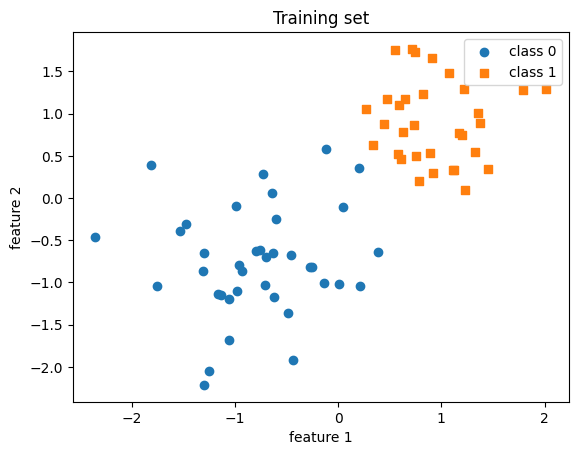

In [6]:
plt.scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
plt.scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')
plt.title('Training set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
# plt.xlim([-3, 3])
# plt.ylim([-3, 3])
plt.legend()
plt.show()


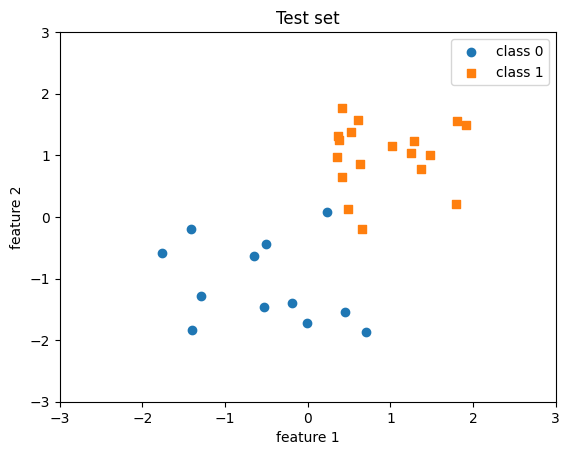

In [7]:
plt.scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
plt.scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')
plt.title('Test set')
plt.xlabel('feature 1')
plt.ylabel('feature 2')
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.legend()
plt.show()


# define Model

In [8]:
class Perceptron:
  def __init__(self, num_feaures):
    self.num_features = num_feaures
    self.weights = np.zeros((num_feaures,1), dtype = float)
    self.bias = np.zeros(1, dtype= float)

  def forward(self, x):
    linear = np.dot(x, self.weights) + self.bias # compute the net input 
    predictions = np.where(linear > 0.0, 1, 0) # this is the threshold
    return predictions 
  
  def backward(self, x, y):
    '''computes the error'''
    predictions = self.forward(x)
    errors= y -predictions
    return errors
  
  def train(self, x, y, epochs):
    for e in range(epochs):

      for i in range(y.shape[0]):
        # reshape the errors to be like rows
        errors = self.backward(x[i].reshape(1, self.num_features), y[i]).reshape(-1)
        self.weights += (errors * x[i]).reshape(self.num_features, 1)
        self.bias += errors


  def evaluate(self, x, y):
    predictions = self.forward(x).reshape(-1)
    accuracy = np.sum(predictions ==y)/y.shape[0]
    return accuracy

# basic Train and Evaluate

In [9]:
ppn = Perceptron(num_feaures= 2)
ppn.train(X_train, y_train, epochs = 10)

print('Model Parameters: \n')
print(f'Weights: {ppn.weights}')
print(f'Bias: {ppn.bias}')

Model Parameters: 

Weights: [[1.27340847]
 [1.34642288]]
Bias: [-1.]


In [10]:
# evaluate the model
test_acc = ppn.evaluate(X_test, y_test)
train_acc  = ppn.evaluate(X_train, y_train)

print(f"Test Set Accuracy: {test_acc*100 :.2f}")
print(f"Train set accuracy: {train_acc :.2f}")

Test Set Accuracy: 93.33
Train set accuracy: 1.00


In [11]:
##########################
### 2D Decision Boundary
##########################

w, b = ppn.weights, ppn.bias

x0_min = -2 # the leftmost x value on plot

# the y value corresponding to x0_min on the plot
x1_min = ( ( - (w[0]*x0_min) - b[0])
          /w[1]) 

x0_max = 2
x1_max = ( (-(w[0] * x0_max) - b[0]) 
          / w[1] )

# x0*w0 + x1*w1 + b = 0
# x1  = (-x0*w0 - b) / w1



In [12]:
[x0_min, x0_max]

[-2, 2]

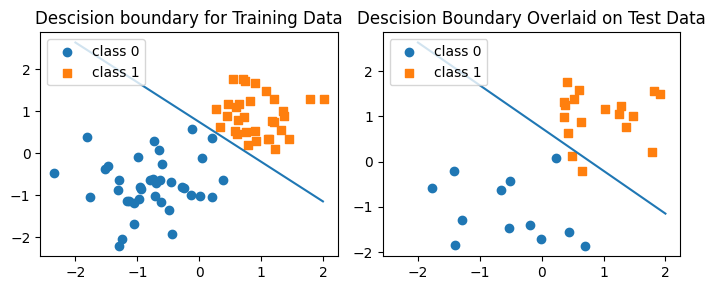

In [13]:

fig, ax = plt.subplots(1,2, sharex = True, figsize = (7,3), tight_layout = True)

ax[0].plot([x0_min, x0_max], [x1_min, x1_max])
ax[0].scatter(X_train[y_train==0, 0], X_train[y_train==0, 1], label='class 0', marker='o')
ax[0].scatter(X_train[y_train==1, 0], X_train[y_train==1, 1], label='class 1', marker='s')
ax[0].legend(loc = 'upper left')
ax[0].set_title('Descision boundary for Training Data')

ax[1].plot([x0_min, x0_max], [x1_min, x1_max])
ax[1].scatter(X_test[y_test==0, 0], X_test[y_test==0, 1], label='class 0', marker='o')
ax[1].scatter(X_test[y_test==1, 0], X_test[y_test==1, 1], label='class 1', marker='s')
ax[1].legend(loc='upper left')
ax[1].set_title('Descision Boundary Overlaid on Test Data')

plt.show()


## CV 

In [ ]:
shuffle_idx = np.arange(y.shape[0])
shuffle_rng = np.random.RandomState(123)
shuffle_rng.shuffle(shuffle_idx)
X, y = X[shuffle_idx], y[shuffle_idx]

X_train, X_test = X[shuffle_idx[:70]], X[shuffle_idx[70:]]
y_train, y_test = y[shuffle_idx[:70]], y[shuffle_idx[70:]]


for i in range(5):
  